In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from tensorflow import keras

print("Libraries ready! ✅")

Libraries ready! ✅


[*********************100%***********************]  1 of 1 completed


Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2024-12-24  256.797211  256.807136  253.903002  254.101927  23234700
2024-12-26  257.612732  258.686881  256.230300  256.787255  27237100
2024-12-27  254.201355  257.294474  251.685102  256.429175  42355300
2024-12-30  250.829773  252.122713  249.387654  250.859609  35557500
2024-12-31  249.059464  251.903926  248.074837  251.068493  39480700

Total trading days: 502


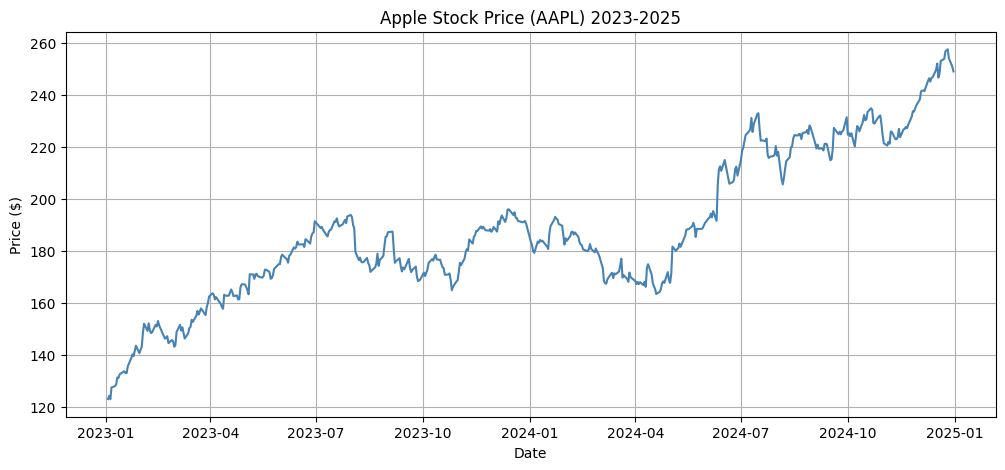

In [2]:
# Download Apple stock data for the last 2 years
stock = yf.download('AAPL', start='2023-01-01', end='2025-01-01')
print(stock.tail())
print(f"\nTotal trading days: {len(stock)}")

plt.figure(figsize=(12, 5))
plt.plot(stock['Close'], color='steelblue')
plt.title('Apple Stock Price (AAPL) 2023-2025')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.grid(True)
plt.show()

In [3]:
data = stock['Close'].values.reshape(-1, 1)
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

# Create sequences of 60 days to predict next day
X, y = [], []
for i in range(60, len(data_scaled)):
    X.append(data_scaled[i-60:i])
    y.append(data_scaled[i])

X, y = np.array(X), np.array(y)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

Training samples: 353
Test samples: 89


In [4]:
model = keras.Sequential([
    keras.layers.LSTM(50, return_sequences=True, input_shape=(60, 1)),
    keras.layers.LSTM(50),
    keras.layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

history = model.fit(X_train, y_train, epochs=20, batch_size=32, 
                    validation_split=0.1, verbose=1)
print("Training complete! ✅")

C:\Users\PC\Desktop\Kenny\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 50)              │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 246ms/step - loss: 0.0577 - val_loss: 0.0104
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0070 - val_loss: 0.0379
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - loss: 0.0039 - val_loss: 0.0051
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0029 - val_loss: 0.0193
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - loss: 0.0025 - val_loss: 0.0095
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 169ms/step - loss: 0.0024 - val_loss: 0.0117
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - loss: 0.0023 - val_loss: 0.0102
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.0022 - val_loss: 0.0088
Epoch 9/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - loss: 0.0021 - val_loss: 0.0091
Epoch 10/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.0020 - val_loss: 0.0066
Epoch 11/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 143ms/step - loss: 0.0019 - val_loss: 0.0079
Epoch 12/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - loss: 

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 309ms/step


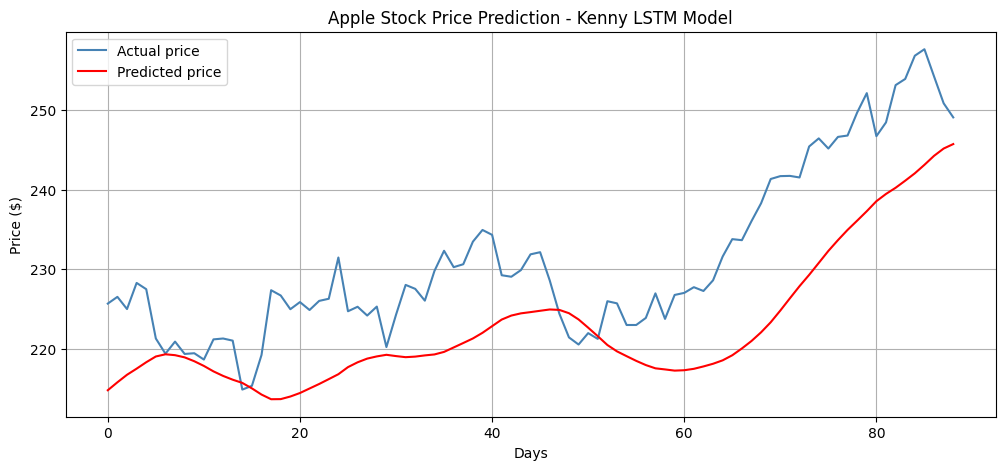

In [5]:
predictions = scaler.inverse_transform(model.predict(X_test))
actual = scaler.inverse_transform(y_test)

plt.figure(figsize=(12, 5))
plt.plot(actual, color='steelblue', label='Actual price')
plt.plot(predictions, color='red', label='Predicted price')
plt.title('Apple Stock Price Prediction - Kenny LSTM Model')
plt.xlabel('Days')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True)
plt.show()